In [86]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


from process_ccf import process_ccf_dataset
from process_ccf import concat_ccf_csv_files



In [ ]:
quiet_output_file = "./CCFs/random_rv_iccf_dataset_soap_spectrum_quiet_step0p1_normalized.parquet"
merged_input_dir = "./hpc_results/random_rv_iccf_datasets_1000"
merged_csv_file = "./hpc_results/random_rv_iccf_datasets_1000_merged.csv"
merged_output_file = "./CCFs/random_rv_iccf_datasets_1000_merged_normalized.parquet"

#merged_df = concat_ccf_csv_files(
#    merged_input_dir,
#    output_path=merged_csv_file,
#)

Found 59 CSV files in hpc_results/random_rv_iccf_datasets_1000
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p05_dT200.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p05_dT400.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p05_dT600.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p05_dT800.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p1_dT200.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p1_dT400.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p1_dT600.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm10_latp0_size0p1_dT800.csv...
Loading hpc_results/random_rv_iccf_datasets_1000/random_rv_iccf_ar1_spot_lonm

In [ ]:
#process_ccf_dataset(merged_csv_file, merged_output_file)

Loading hpc_results/random_rv_iccf_datasets_1000_merged.csv...
Rounded rv_true_mps to 2 decimals
Normalized CCFs
Rounded CCFs to 4 decimals
Saving to CCFs/random_rv_iccf_datasets_1000_merged_normalized.parquet...
Done!


In [109]:
# Load quiet and active datasets, then merge them into one modeling table
quiet_df = pd.read_parquet(Path(quiet_output_file))
active_df = pd.read_parquet(Path(merged_output_file))

quiet_df = quiet_df.copy()
active_df = active_df.copy()
quiet_df["dataset_label"] = "quiet"
active_df["dataset_label"] = "active"

full_df = pd.concat([quiet_df, active_df], axis=0, ignore_index=True)

print("Quiet dataset:", quiet_df.shape)
print("Active dataset:", active_df.shape)
print("Merged dataset:", full_df.shape)
full_df.head()

Quiet dataset: (50000, 309)
Active dataset: (59000, 309)
Merged dataset: (109000, 309)


,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300,dataset_label
0,77.40,-146.693695,6.597320,-35.303705,-28.251487,-603.388779,56.713954,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9882,0.9882,0.9881,quiet
1,43.89,-180.204276,6.597626,-35.453621,-27.440173,-603.794378,56.714368,0.9788,0.9788,0.9787,...,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9882,0.9881,quiet
2,85.86,-138.228632,6.597244,-35.267085,-28.472872,-603.333098,56.713862,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9881,quiet
3,69.74,-154.353225,6.597390,-35.335859,-28.055823,-603.456774,56.714041,0.9788,0.9788,0.9787,...,0.9884,0.9883,0.9883,0.9882,0.9882,0.9882,0.9882,0.9882,0.9881,quiet
4,9.42,-214.676058,6.597961,-35.210673,-29.142251,-601.875318,56.714733,0.9788,0.9787,0.9787,...,0.9883,0.9883,0.9883,0.9882,0.9882,0.9881,0.9882,0.9881,0.9881,quiet


In [117]:
(active_df['rv_true_mps'] - active_df['rv_iccf_mps']).describe()

count    59000.000000
mean       218.432756
std         10.486595
min        171.110763
25%        217.133061
50%        222.619547
75%        223.838995
max        231.744050
dtype: float64

In [116]:
(quiet_df['rv_true_mps'] - quiet_df['rv_iccf_mps']).describe()

count    50000.000000
mean       224.091506
std          0.003618
min        224.083085
25%        224.088985
50%        224.091508
75%        224.094164
max        224.099260
dtype: float64

In [115]:
(full_df['rv_true_mps'] - full_df['rv_iccf_mps']).describe()

count    109000.000000
mean        221.028513
std           8.214300
min         171.110763
25%         222.214570
50%         224.087140
75%         224.093264
max         231.744050
dtype: float64

In [110]:
full_output_file = "./CCFs/full_iccf_dataset_normalized.parquet"
full_df.to_parquet(full_output_file, index=False)
print("Saved:", full_output_file, full_df.shape)


Saved: ./CCFs/full_iccf_dataset_normalized.parquet (109000, 309)


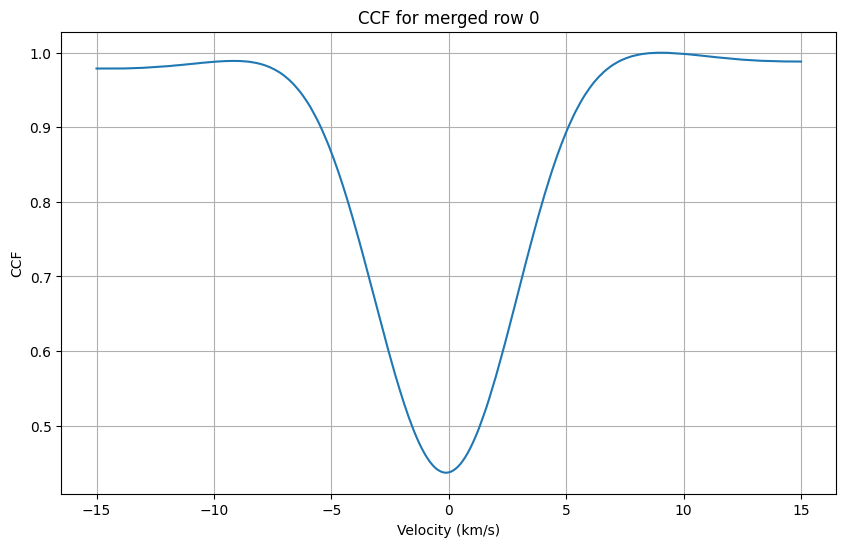

In [90]:
# Plot CCF for a given row
row_index = 0  # Change this to the desired row index
velocities = np.arange(-15, 15.1, 0.1)
ccf_columns = [f'ccf_{i:04d}' for i in range(301)]
ccf_values = full_df.loc[row_index, ccf_columns].values

plt.figure(figsize=(10, 6))
plt.plot(velocities, ccf_values)
plt.xlabel('Velocity (km/s)')
plt.ylabel('CCF')
plt.title(f'CCF for merged row {row_index}')
plt.grid(True)
plt.show()

In [91]:
ccf_cols = [c for c in full_df.columns if c.startswith("ccf_")]

X = full_df[ccf_cols].to_numpy(dtype=np.float32)
y = pd.to_numeric(full_df["rv_true_mps"], errors="coerce").to_numpy(dtype=np.float32).reshape(-1, 1)

In [92]:
# Split merged quiet+active dataset into train/dev/test: 70% / 15% / 15%
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, shuffle=True
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Dev:  ", X_dev.shape, y_dev.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (76300, 301) (76300, 1)
Dev:   (16350, 301) (16350, 1)
Test:  (16350, 301) (16350, 1)


In [93]:
# Scale features and target for stable training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_dev_s = x_scaler.transform(X_dev)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train)
y_dev_s = y_scaler.transform(y_dev)
y_test_s = y_scaler.transform(y_test)


In [104]:
# Simple MLP baseline
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(64, activation="relu"),
    #layers.Dropout(0.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.7,
        patience=10,
        min_lr=1e-5,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]


history = model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_dev_s, y_dev_s),
    epochs=500,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1064 - mae: 0.1501 - val_loss: 0.0033 - val_mae: 0.0380 - learning_rate: 0.0010
Epoch 2/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0025 - mae: 0.0348 - val_loss: 0.0044 - val_mae: 0.0465 - learning_rate: 0.0010
Epoch 3/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - mae: 0.0284 - val_loss: 0.0031 - val_mae: 0.0390 - learning_rate: 0.0010
Epoch 4/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0012 - mae: 0.0246 - val_loss: 0.0013 - val_mae: 0.0249 - learning_rate: 0.0010
Epoch 5/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013 - mae: 0.0245 - val_loss: 7.0807e-04 - val_mae: 0.0191 - learning_rate: 0.0010
Epoch 6/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.6683e-04 - mae: 0.0196 - val_loss: 6.8561e-04 - val_mae: 0.0185 - learning_rate: 0.0010
Epoch 7/500
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.4373e-04 - mae: 0.0193 - val_loss: 0.0018 - val_mae: 0.0281 - learn

In [105]:
def evaluate_regression(model, X_s, y_true, scaler, split_name):
    y_pred_s = model.predict(X_s, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_s).ravel()
    y_true = y_true.ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)

    print(f"{split_name} -> MAE: {mae:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return y_pred

y_dev_pred = evaluate_regression(model, X_dev_s, y_dev, y_scaler, "Dev")
y_test_pred = evaluate_regression(model, X_test_s, y_test, y_scaler, "Test")


Dev -> MAE: 0.122513, RMSE: 0.183158, R2: 0.999960
Test -> MAE: 0.122193, RMSE: 0.185565, R2: 0.999959


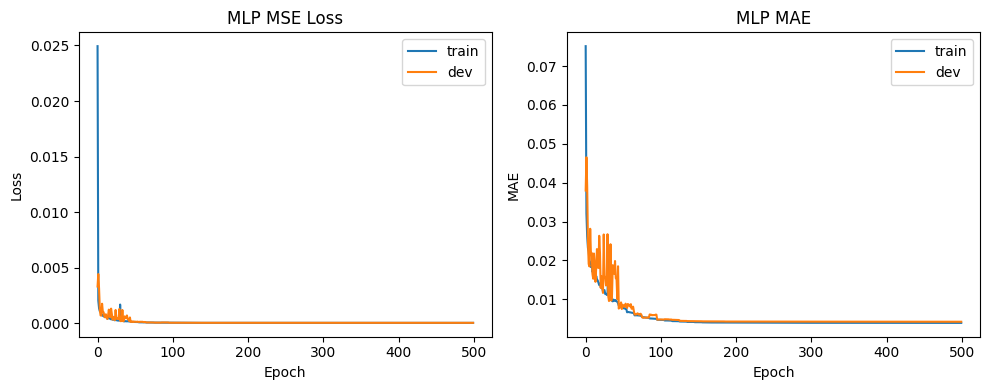

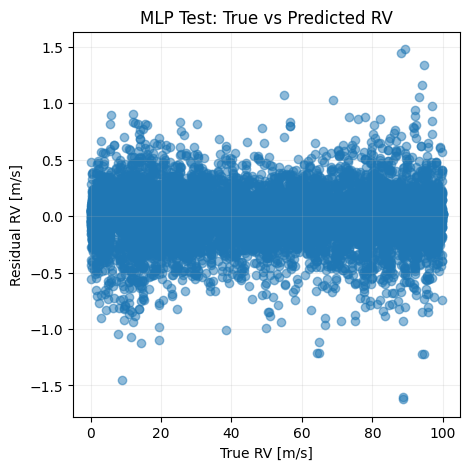

In [106]:
# MLP training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="dev")
plt.title("MLP MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="dev")
plt.title("MLP MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# MLP prediction scatter on test split
plt.figure(figsize=(5, 5))
plt.scatter(y_test.ravel(), y_test.ravel() - y_test_pred, alpha=0.5)
min_v = min(y_test.min(), y_test_pred.min())
max_v = max(y_test.max(), y_test_pred.max())
#plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual RV [m/s]")
plt.title("MLP Test: True vs Predicted RV")
plt.grid(True, alpha=0.2)
plt.show()
